# AI Project

## Predicting Students' Adaptability to Online Learning

# 1. Import Libraries

In [ ]:
# Import libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier

from sklearn.feature_selection import mutual_info_classif

from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix
from sklearn.metrics import ConfusionMatrixDisplay

# 2. Load Dataset

In [ ]:
# Load dataset

df = pd.read_csv('/content/students_adaptability_level_online_education.csv')

# Display first 5 rows
df.head()

,Gender,Age,Education Level,Institution Type,IT Student,Location,Load-shedding,Financial Condition,Internet Type,Network Type,Class Duration,Self Lms,Device,Adaptivity Level
0,Boy,21-25,University,Non Government,No,Yes,Low,Mid,Wifi,4G,03-Jun,No,Tab,High
1,Girl,21-25,University,Non Government,No,Yes,High,Mid,Mobile Data,4G,01-Mar,Yes,Mobile,High
2,Girl,16-20,College,Government,No,Yes,Low,Mid,Wifi,4G,01-Mar,No,Mobile,High
3,Girl,Nov-15,School,Non Government,No,Yes,Low,Mid,Mobile Data,4G,01-Mar,No,Mobile,High
4,Girl,16-20,School,Non Government,No,Yes,Low,Poor,Mobile Data,3G,0,No,Mobile,Low


# 3. Basic Dataset Information

In [ ]:
# Check dataset size

print("Dataset shape:", df.shape)

print("\nColumns:")
print(df.columns)

print("\nData types:")
print(df.dtypes)

print("\nFirst 5 rows:")
display(df.head())

Dataset shape: (1205, 14)

Columns:
Index(['Gender', 'Age', 'Education Level', 'Institution Type', 'IT Student',
       'Location', 'Load-shedding', 'Financial Condition', 'Internet Type',
       'Network Type', 'Class Duration', 'Self Lms', 'Device',
       'Adaptivity Level'],
      dtype='object')

Data types:
Gender                 object
Age                    object
Education Level        object
Institution Type       object
IT Student             object
Location               object
Load-shedding          object
Financial Condition    object
Internet Type          object
Network Type           object
Class Duration         object
Self Lms               object
Device                 object
Adaptivity Level       object
dtype: object

First 5 rows:


,Gender,Age,Education Level,Institution Type,IT Student,Location,Load-shedding,Financial Condition,Internet Type,Network Type,Class Duration,Self Lms,Device,Adaptivity Level
0,Boy,21-25,University,Non Government,No,Yes,Low,Mid,Wifi,4G,03-Jun,No,Tab,High
1,Girl,21-25,University,Non Government,No,Yes,High,Mid,Mobile Data,4G,01-Mar,Yes,Mobile,High
2,Girl,16-20,College,Government,No,Yes,Low,Mid,Wifi,4G,01-Mar,No,Mobile,High
3,Girl,Nov-15,School,Non Government,No,Yes,Low,Mid,Mobile Data,4G,01-Mar,No,Mobile,High
4,Girl,16-20,School,Non Government,No,Yes,Low,Poor,Mobile Data,3G,0,No,Mobile,Low


# 4. Check Target Distribution

Target variable distribution:
Adaptivity Level
High    725
Low     480
Name: count, dtype: int64


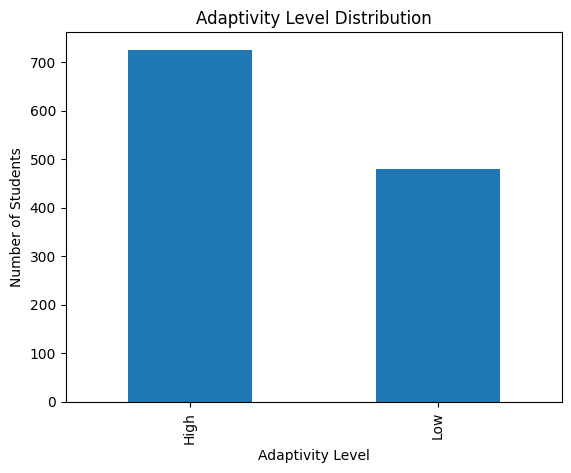

In [ ]:
# Check target class distribution

print("Target variable distribution:")
print(df['Adaptivity Level'].value_counts())

# Plot target distribution
df['Adaptivity Level'].value_counts().plot(kind='bar')
plt.title('Adaptivity Level Distribution')
plt.xlabel('Adaptivity Level')
plt.ylabel('Number of Students')
plt.show()

# 5. Check Missing Values, Duplicates, and Fix Inconsistent Values

In [ ]:
# Check missing values

print("Missing values in each column:")
print(df.isnull().sum())

# Check duplicate rows
print("\nNumber of duplicate rows:")
print(df.duplicated().sum())

# Check unique values before cleaning
print("\nUnique values in Age before cleaning:")
print(df['Age'].unique())

print("\nUnique values in Class Duration before cleaning:")
print(df['Class Duration'].unique())

# Fix inconsistent values caused by date formatting
df['Age'] = df['Age'].replace({
    'Nov-15': '11-15',
    '01-May': '1-5',
    '06-Oct': '6-10'
})

df['Class Duration'] = df['Class Duration'].replace({
    '01-Mar': '1-3',
    '03-Jun': '3-6'
})

# Check unique values after cleaning
print("\nUnique values in Age after cleaning:")
print(df['Age'].unique())

print("\nUnique values in Class Duration after cleaning:")
print(df['Class Duration'].unique())

Missing values in each column:
Gender                 0
Age                    0
Education Level        0
Institution Type       0
IT Student             0
Location               0
Load-shedding          0
Financial Condition    0
Internet Type          0
Network Type           0
Class Duration         0
Self Lms               0
Device                 0
Adaptivity Level       0
dtype: int64

Number of duplicate rows:
954

Unique values in Age before cleaning:
['21-25' '16-20' 'Nov-15' '26-30' '06-Oct' '01-May']

Unique values in Class Duration before cleaning:
['03-Jun' '01-Mar' '0']

Unique values in Age after cleaning:
['21-25' '16-20' '11-15' '26-30' '6-10' '1-5']

Unique values in Class Duration after cleaning:
['3-6' '1-3' '0']


# 6. Label Encoding

In [ ]:
# Make a copy of the dataset

data = df.copy()

# Encode input features
label_encoders = {}

for column in data.columns:
    if column != 'Adaptivity Level':
        labelencoder = LabelEncoder()
        data[column] = labelencoder.fit_transform(data[column])
        label_encoders[column] = labelencoder

# Encode target variable separately
target_encoder = LabelEncoder()
data['Adaptivity Level'] = target_encoder.fit_transform(data['Adaptivity Level'])

print("Target classes:")
print(target_encoder.classes_)

print("\nEncoded dataset:")
display(data.head())

Target classes:
['High' 'Low']

Encoded dataset:


,Gender,Age,Education Level,Institution Type,IT Student,Location,Load-shedding,Financial Condition,Internet Type,Network Type,Class Duration,Self Lms,Device,Adaptivity Level
0,0,3,2,1,0,1,1,0,1,2,2,0,2,0
1,1,3,2,1,0,1,0,0,0,2,1,1,1,0
2,1,2,0,0,0,1,1,0,1,2,1,0,1,0
3,1,1,1,1,0,1,1,0,0,2,1,0,1,0
4,1,2,1,1,0,1,1,1,0,1,0,0,1,1


# 7. Feature Selection / Feature Importance

Feature importance using information gain:


,Feature,Information Gain
10,Class Duration,0.100555
3,Institution Type,0.044122
5,Location,0.032741
7,Financial Condition,0.021278
1,Age,0.017179
12,Device,0.016102
2,Education Level,0.011137
9,Network Type,0.010807
11,Self Lms,0.010525
4,IT Student,0.008063


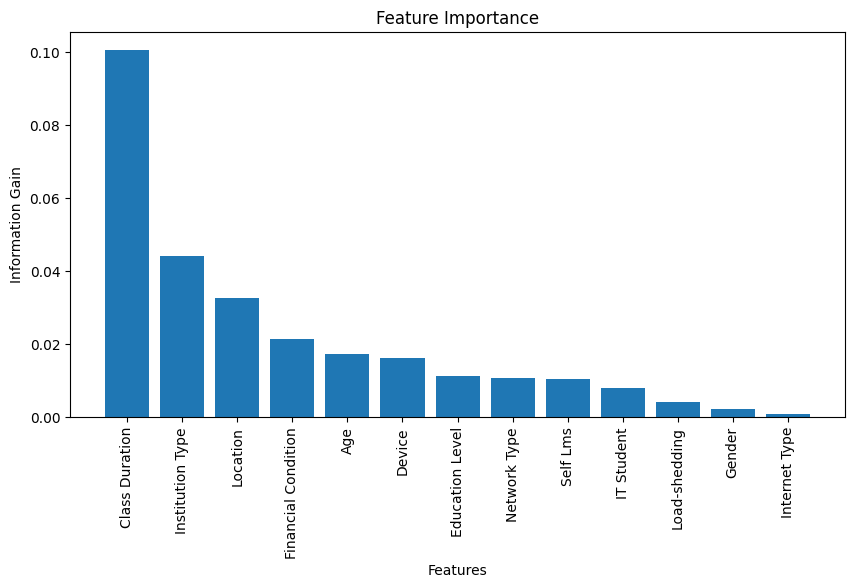

In [ ]:
# Split features and target

X = data.drop('Adaptivity Level', axis=1)
y = data['Adaptivity Level']

# Calculate information gain
info_gain = mutual_info_classif(X, y, discrete_features=True, random_state=42)

# Store feature scores in dataframe
feature_scores = pd.DataFrame({
    'Feature': X.columns,
    'Information Gain': info_gain
})

# Sort from highest to lowest
feature_scores = feature_scores.sort_values(by='Information Gain', ascending=False)

print("Feature importance using information gain:")
display(feature_scores)

# Plot feature importance
plt.figure(figsize=(10, 5))
plt.bar(feature_scores['Feature'], feature_scores['Information Gain'])
plt.xlabel('Features')
plt.ylabel('Information Gain')
plt.title('Feature Importance')
plt.xticks(rotation=90)
plt.show()

# 8. Train/Test Split and Scaling

In [ ]:
# Split data into training and testing sets

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training set size:", X_train.shape)
print("Testing set size:", X_test.shape)

# Apply MinMax scaling
# Scaling is useful for Logistic Regression and KNN

scaler = MinMaxScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

Training set size: (964, 13)
Testing set size: (241, 13)


# 9. Train 3 Algorithms, Each with 2 Configurations

In [ ]:
# Create list to store all results
results = []

# Function to train and evaluate model
def train_and_evaluate(model_name, model, use_scaled_data):

    print("\n====================================")
    print("Model:", model_name)
    print("====================================")

    # Use scaled data for Logistic Regression and KNN
    if use_scaled_data == True:
        model.fit(X_train_scaled, y_train)
        y_pred = model.predict(X_test_scaled)
    else:
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)

    # Calculate metrics
    accuracy = accuracy_score(y_test, y_pred)
    precision_low = precision_score(y_test, y_pred, pos_label=1)
    recall_low = recall_score(y_test, y_pred, pos_label=1)
    f1_low = f1_score(y_test, y_pred, pos_label=1)
    macro_f1 = f1_score(y_test, y_pred, average='macro')

    # Print metrics
    print("Accuracy:", accuracy)
    print("Precision for Low:", precision_low)
    print("Recall for Low:", recall_low)
    print("F1-score for Low:", f1_low)
    print("Macro F1-score:", macro_f1)

    # Print classification report
    print("\nClassification Report:")
    print(classification_report(
        y_test,
        y_pred,
        target_names=target_encoder.classes_
    ))

    # Confusion matrix
    cm = confusion_matrix(y_test, y_pred, labels=[0, 1])

    print("\nConfusion Matrix:")
    cm_df = pd.DataFrame(
        cm,
        index=['Actual High', 'Actual Low'],
        columns=['Predicted High', 'Predicted Low']
    )
    display(cm_df)

    # Plot confusion matrix
    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=target_encoder.classes_
    )
    disp.plot()
    plt.title(model_name)
    plt.show()

    # Store results
    results.append({
        'Model': model_name,
        'Accuracy': accuracy,
        'Precision Low': precision_low,
        'Recall Low': recall_low,
        'F1 Low': f1_low,
        'Macro F1': macro_f1
    })

# 10. Run All 6 Experiments


Model: Logistic Regression C=1.0
Accuracy: 0.7510373443983402
Precision for Low: 0.7571428571428571
Recall for Low: 0.5520833333333334
F1-score for Low: 0.6385542168674698
Macro F1-score: 0.7243403995729754

Classification Report:
              precision    recall  f1-score   support

        High       0.75      0.88      0.81       145
         Low       0.76      0.55      0.64        96

    accuracy                           0.75       241
   macro avg       0.75      0.72      0.72       241
weighted avg       0.75      0.75      0.74       241


Confusion Matrix:


,Predicted High,Predicted Low
Actual High,128,17
Actual Low,43,53


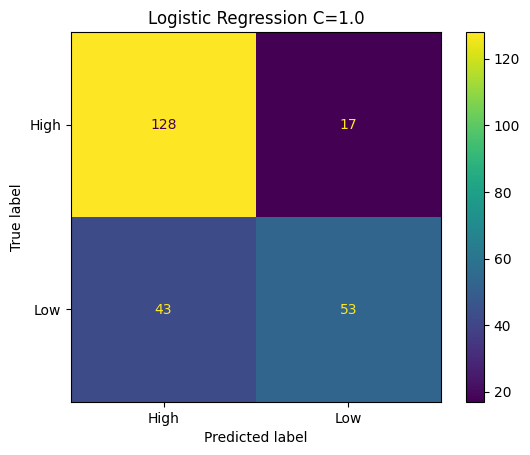


Model: Logistic Regression C=0.5
Accuracy: 0.7468879668049793
Precision for Low: 0.7611940298507462
Recall for Low: 0.53125
F1-score for Low: 0.6257668711656442
Macro F1-score: 0.7172721503163644

Classification Report:
              precision    recall  f1-score   support

        High       0.74      0.89      0.81       145
         Low       0.76      0.53      0.63        96

    accuracy                           0.75       241
   macro avg       0.75      0.71      0.72       241
weighted avg       0.75      0.75      0.74       241


Confusion Matrix:


,Predicted High,Predicted Low
Actual High,129,16
Actual Low,45,51


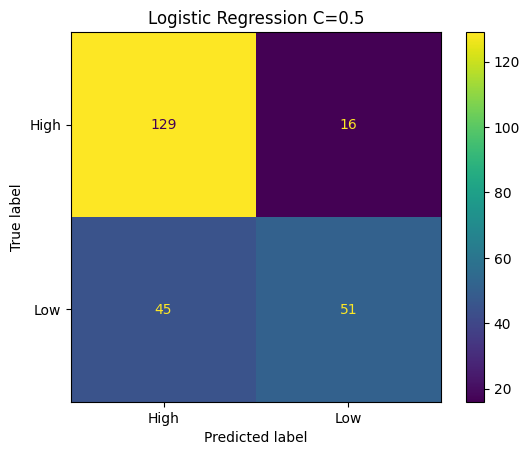


Model: Decision Tree max_depth=3 gini
Accuracy: 0.7219917012448133
Precision for Low: 0.7636363636363637
Recall for Low: 0.4375
F1-score for Low: 0.5562913907284768
Macro F1-score: 0.6769372361497369

Classification Report:
              precision    recall  f1-score   support

        High       0.71      0.91      0.80       145
         Low       0.76      0.44      0.56        96

    accuracy                           0.72       241
   macro avg       0.74      0.67      0.68       241
weighted avg       0.73      0.72      0.70       241


Confusion Matrix:


,Predicted High,Predicted Low
Actual High,132,13
Actual Low,54,42


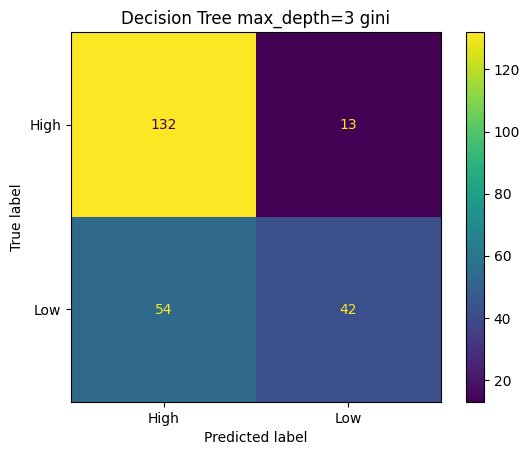


Model: Decision Tree max_depth=6 entropy
Accuracy: 0.7593360995850622
Precision for Low: 0.6826923076923077
Recall for Low: 0.7395833333333334
F1-score for Low: 0.71
Macro F1-score: 0.7521631205673759

Classification Report:
              precision    recall  f1-score   support

        High       0.82      0.77      0.79       145
         Low       0.68      0.74      0.71        96

    accuracy                           0.76       241
   macro avg       0.75      0.76      0.75       241
weighted avg       0.76      0.76      0.76       241


Confusion Matrix:


,Predicted High,Predicted Low
Actual High,112,33
Actual Low,25,71


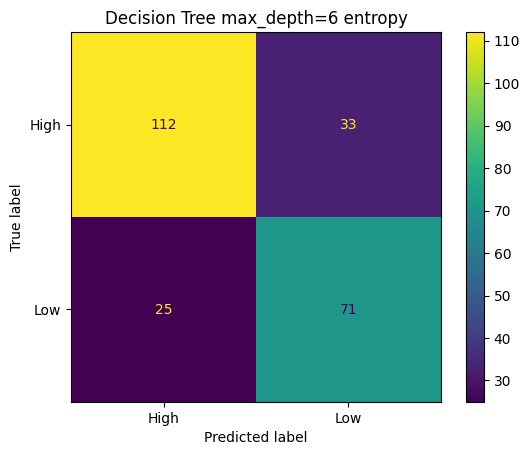


Model: KNN k=3
Accuracy: 0.8464730290456431
Precision for Low: 0.8172043010752689
Recall for Low: 0.7916666666666666
F1-score for Low: 0.8042328042328042
Macro F1-score: 0.8389764703757878

Classification Report:
              precision    recall  f1-score   support

        High       0.86      0.88      0.87       145
         Low       0.82      0.79      0.80        96

    accuracy                           0.85       241
   macro avg       0.84      0.84      0.84       241
weighted avg       0.85      0.85      0.85       241


Confusion Matrix:


,Predicted High,Predicted Low
Actual High,128,17
Actual Low,20,76


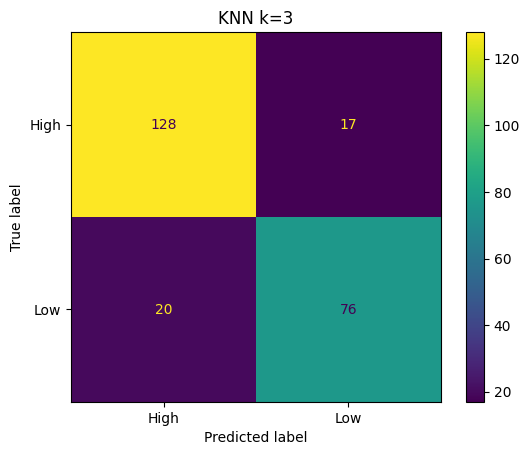


Model: KNN k=7
Accuracy: 0.7800829875518672
Precision for Low: 0.7362637362637363
Recall for Low: 0.6979166666666666
F1-score for Low: 0.7165775401069518
Macro F1-score: 0.7684582615788996

Classification Report:
              precision    recall  f1-score   support

        High       0.81      0.83      0.82       145
         Low       0.74      0.70      0.72        96

    accuracy                           0.78       241
   macro avg       0.77      0.77      0.77       241
weighted avg       0.78      0.78      0.78       241


Confusion Matrix:


,Predicted High,Predicted Low
Actual High,121,24
Actual Low,29,67


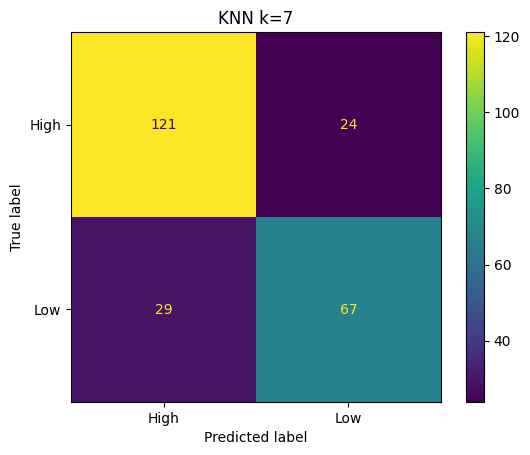

In [ ]:
# Logistic Regression, configuration 1
model1 = LogisticRegression(C=1.0, max_iter=1000, random_state=42)
train_and_evaluate("Logistic Regression C=1.0", model1, True)

# Logistic Regression, configuration 2
model2 = LogisticRegression(C=0.5, max_iter=1000, random_state=42)
train_and_evaluate("Logistic Regression C=0.5", model2, True)

# Decision Tree, configuration 1
model3 = DecisionTreeClassifier(max_depth=3, criterion='gini', random_state=42)
train_and_evaluate("Decision Tree max_depth=3 gini", model3, False)

# Decision Tree, configuration 2
model4 = DecisionTreeClassifier(max_depth=6, criterion='entropy', random_state=42)
train_and_evaluate("Decision Tree max_depth=6 entropy", model4, False)

# KNN, configuration 1
model5 = KNeighborsClassifier(n_neighbors=3)
train_and_evaluate("KNN k=3", model5, True)

# KNN, configuration 2
model6 = KNeighborsClassifier(n_neighbors=7)
train_and_evaluate("KNN k=7", model6, True)